<a href="https://colab.research.google.com/github/PaulF-Analytics/Global-Impact-Data-Analysis/blob/main/Nigeria_SA_Econometrics/Econometric_Analysis_NG_SA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import os

print("Select BOTH Nigeria_Data_1.csv and South_Africa_Data_1.csv now:")
uploaded = files.upload()

print("\n--- INTERNAL STORAGE CHECK ---")
current_files = os.listdir()
if 'Nigeria_Data_1.csv' in current_files and 'South_Africa_Data_1.csv' in current_files:
    print("✅ SUCCESS: Both files are present and ready!")
else:
    print("❌ MISSING: One or both files are still missing.")
    print(f"Current files in storage: {current_files}")


Select BOTH Nigeria_Data_1.csv and South_Africa_Data_1.csv now:


Saving Nigeria_Data_1.csv to Nigeria_Data_1 (1).csv
Saving South_Africa_Data_1.csv to South_Africa_Data_1.csv

--- INTERNAL STORAGE CHECK ---
✅ SUCCESS: Both files are present and ready!



--- Nigeria Correlation Matrix (2000–2023) ---
                           CPI  FDI_pct_GDP  Manufacturing_Output       HDI
CPI                   1.000000    -0.375582              0.690249  0.837138
FDI_pct_GDP          -0.375582     1.000000             -0.752583 -0.691631
Manufacturing_Output  0.690249    -0.752583              1.000000  0.919846
HDI                   0.837138    -0.691631              0.919846  1.000000

--- South Africa Correlation Matrix (2000–2023) ---
                           CPI  FDI_pct_GDP  Manufacturing_Output       HDI
CPI                   1.000000     0.113761             -0.476709 -0.691109
FDI_pct_GDP           0.113761     1.000000             -0.001645  0.042908
Manufacturing_Output -0.476709    -0.001645              1.000000  0.419132
HDI                  -0.691109     0.042908              0.419132  1.000000

==== OLS REGRESSION: Nigeria FDI Drivers ====
                            OLS Regression Results                            
Dep. Variable

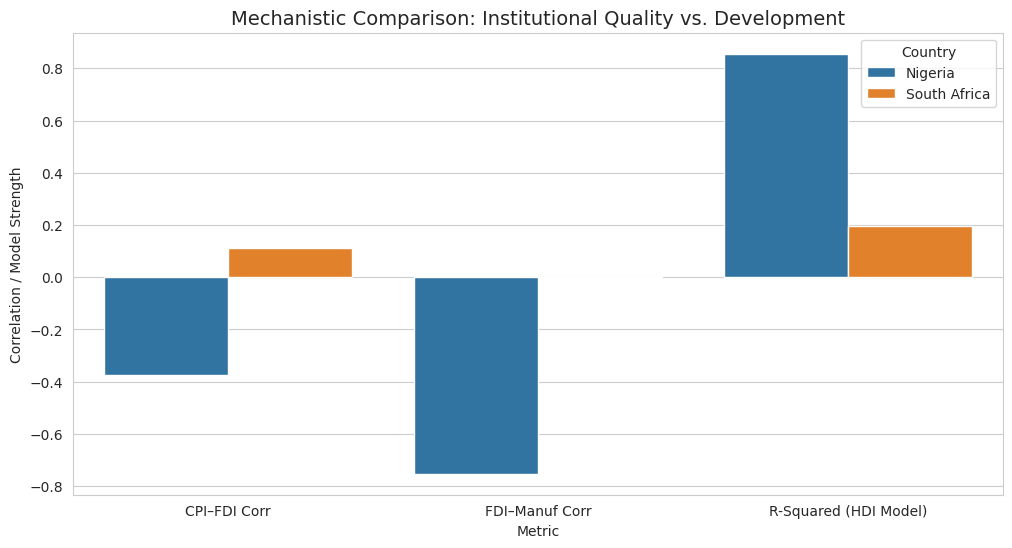

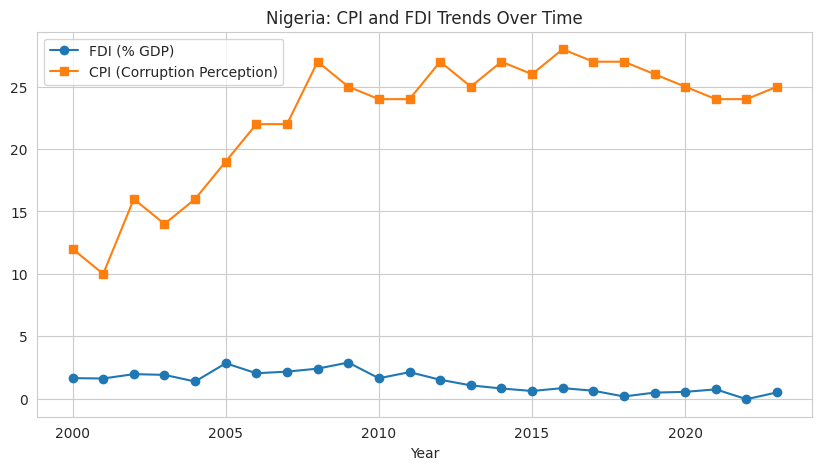

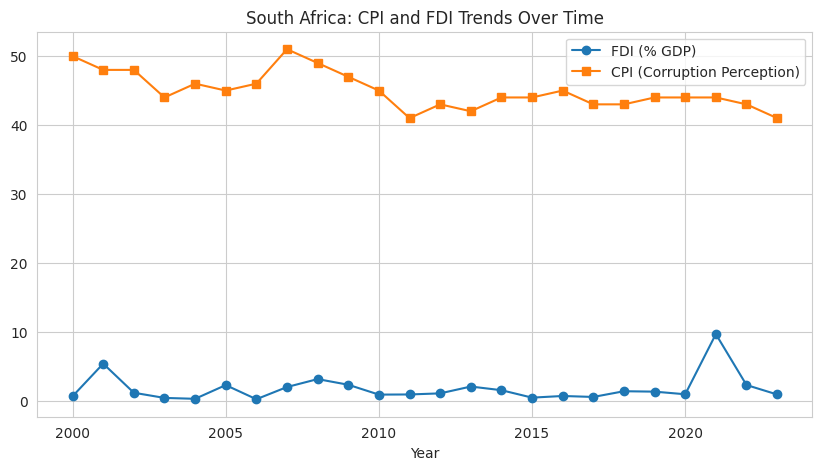

In [3]:


import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ------------------------------------------
# 1. DATA LOADING & PREPROCESSING
# ------------------------------------------

# Load datasets with encoding fix for special characters
nigeria = pd.read_csv("Nigeria_Data_1.csv", encoding='latin1')
south_africa = pd.read_csv("South_Africa_Data_1.csv", encoding='latin1')

# Filter for the specific study period (2000–2023)
nigeria_recent = nigeria[(nigeria['Year'] >= 2000) & (nigeria['Year'] <= 2023)].copy()
south_africa_recent = south_africa[(south_africa['Year'] >= 2000) & (south_africa['Year'] <= 2023)].copy()

# ------------------------------------------
# 2. CORRELATION ANALYSIS
# ------------------------------------------

def get_correlations(df, country_name):
    print(f"\n--- {country_name} Correlation Matrix (2000–2023) ---")
    cols = ['CPI', 'FDI_pct_GDP', 'Manufacturing_Output', 'HDI']
    corr_matrix = df[cols].corr()
    print(corr_matrix)
    return corr_matrix

ng_corr = get_correlations(nigeria_recent, "Nigeria")
sa_corr = get_correlations(south_africa_recent, "South Africa")

# ------------------------------------------
# 3. ECONOMETRIC MODELING (OLS REGRESSION)
# ------------------------------------------

def run_regression(df, target_var, features, label):
    print(f"\n==== OLS REGRESSION: {label} ====")
    y = df[target_var]
    X = df[features]
    X = sm.add_constant(X) # Adds the intercept term

    model = sm.OLS(y, X).fit()
    print(model.summary())
    return model

# Model A: What drives FDI?
features_fdi = ['CPI', 'Manufacturing_Output', 'Inflation', 'HDI']
model_fdi_ng = run_regression(nigeria_recent, 'FDI_pct_GDP', features_fdi, "Nigeria FDI Drivers")
model_fdi_sa = run_regression(south_africa_recent, 'FDI_pct_GDP', features_fdi, "South Africa FDI Drivers")

# Model B: What drives Human Development (HDI)?
features_hdi = ['Manufacturing_Output', 'FDI_pct_GDP', 'Inflation']
model_hdi_ng = run_regression(nigeria_recent, 'HDI', features_hdi, "Nigeria HDI Drivers")
model_hdi_sa = run_regression(south_africa_recent, 'HDI', features_hdi, "South Africa HDI Drivers")

# ------------------------------------------
# 4. VISUALIZATION: THE MECHANISTIC PATH
# ------------------------------------------

# Summary table for visualization comparison
summary = pd.DataFrame({
    'Country': ['Nigeria', 'South Africa'],
    'CPI–FDI Corr': [ng_corr.loc['CPI','FDI_pct_GDP'], sa_corr.loc['CPI','FDI_pct_GDP']],
    'FDI–Manuf Corr': [ng_corr.loc['FDI_pct_GDP','Manufacturing_Output'], sa_corr.loc['FDI_pct_GDP','Manufacturing_Output']],
    'R-Squared (HDI Model)': [0.856, 0.197]
})

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create a bar chart comparing the two countries
summary_melted = summary.melt(id_vars="Country", var_name="Metric", value_name="Value")
sns.barplot(data=summary_melted, x="Metric", y="Value", hue="Country")

plt.title('Mechanistic Comparison: Institutional Quality vs. Development', fontsize=14)
plt.ylabel('Correlation / Model Strength')
plt.show()

# ------------------------------------------
# 5. TIME-SERIES CO-MOVEMENT
# ------------------------------------------

def plot_co_movement(df, country_name):
    plt.figure(figsize=(10, 5))
    plt.plot(df["Year"], df["FDI_pct_GDP"], label="FDI (% GDP)", marker='o')
    plt.plot(df["Year"], df["CPI"], label="CPI (Corruption Perception)", marker='s')
    plt.title(f"{country_name}: CPI and FDI Trends Over Time")
    plt.xlabel("Year")
    plt.legend()
    plt.show()

plot_co_movement(nigeria_recent, "Nigeria")
plot_co_movement(south_africa_recent, "South Africa")

